# 

# Theoritische Grundlagen

## Infinite Impulse Response (IIR)-Filter

Infinite Impulse Response (IIR) Filter gehören in der Signalverarbeitung zu den grundlegenden Typen der digitalen Filter. IIR-Filter zeichnen sich fundamental durch ihre characteristik aus, bei der Berechnung des aktuellen Ausgangswertes durch die Verwendung des gegenwärtigen und vergangenen Eingabewertes als auch des vorherigen Ausgabewertes. Aufgrund dieser Rückkopplung kann es dazu führen, dass die Impulsantwort von IIR-Filtern theoretisch unendlich lang andauern kann, was sie grundsätzlich von Finite Impulse Response (FIR) Filtern unterscheidet.

Ein immenser Vorteil von IIR-Filtern liegt in der hohen Effizienz bei der Realisierung scharfter Frequenzgänge mit relativ wenigen Koeffizienten, während FIR-Filter für vergleichbare Filtereigenschaften oft hunderte von Koeffizienten benötigen, können IIR-Filter ähnliche Ergebnisse mit deutlich geringerem Rechenaufwand erreichen. Aufgrund dieser Eigenschaft eignen sich IIR-Filter besonders gut im Einsatz von Systemen mit beschränkten Ressourcen oder in Echtzeitverarbeitung.

Biquadratische Filter, kurz als “Biquad” bezeichnet, sind eine spezielle Unterklasse von IIR-Filtern zweiter Ordnung. Durch das Kaskadieren solcher Biquad-Sektionen besteht die möglichkeit komplexe IIR-Filter höhrer Ordnung auf einfache Weise zu realsieren. Das Kaskadieren dieser Sektionen bringt Vorteile in Bezug auf numerische Stabilität, Flexibilät bei der Parameteranpassung und Modularität des Designs.

## Differenzengleichung eines IIR Filters zweiter Ordnung

Digitale Filter können mit einer linearen Differenzengleichung beschrieben werden. Differenzengleichung des Biquad-Filters:

$$
y[n] =  \frac{1}{a_0}(b_0 \cdot x[n] + b_1 \cdot x[n - 1] + b_2 \cdot x[n - 2] - a_1 \cdot y[n - 1] - a_2 \cdot y[n - 2])
$$

Der Wert $y[n]$ bezeichnet den Ausgabewert zum Sample $n$, während $x[n]$ den Eingangswert darstellt. Der aktuelle Ausgabewert $y[n]$ ergibt sich aus der gewichteten Summe der aktuellen und zwei vergangenen Eingabewerte, subtrahiert mit den zwei gewichteten vergangen Ausgabewerte. Die Koeffizienten $b_0$, $b_1$ und $b_2$ bestimmen den Einfluss des aktuellen und der vergangenen Eingabewerte (Feedforward), während $a_1$ und $a_2$ den Rückkopplungsanteil aus früheren Ausgabewerten (Feedback) modellieren. Im Allgemeinem wird der Koeffizient auf $a_0$ auf 1 normiert: $$
y[n] = b_0 \cdot x[n] + b_1 \cdot x[n - 1] + b_2 \cdot x[n - 2] - a_1 \cdot y[n - 1] - a_2 \cdot y[n - 2]
$$ Zur Analyse des Frequenz- und Phasenverhaltens des Filters, wird die Differenzengleichung mittles der z-Transformation in den z-Bereich transformiert und daraus folgt die folgende Übertragunsfunktion.

## Übertragungsfunktion eines IIR-Filters zweiter Ordnung

$$
H(z) = \frac{Y(z)}{X(z)} = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{1 + a_1 z^{-1} + a_2 z^{-2}}
$$ Bei dieser rationalen Funktion wird das Verhälnis zwischen Ausgang zu Eingang im Frequenzbereich beschrieben. Um die Stabilität des Biquad-Filters zu vergewissern, müssen alle Polstellen des Filters innerhalb des Einheitskreises der z-Ebene liegen.

# Implementierungsstrukturen biquadratischer Filter

Die praktische Implementierung von biquaratischen Filtern erfolgt durch die direkte Umsetzung der Differezengleichungen in Software oder Hardware.

Dafür werden die verzögerten Eingangswerte $x[n-1]$ und $x[n-2]$, sowie die Ausgangswerte $y[n-1]$ und $y[n-2]$ in Speicherelementen, sogenannten Verzögerungsgliedern, gespeichert. Der aktuelle Ausgangswert $y[n]$ wird mittels der gewichteten Summation aller Terme gemäß der jeweiligen Differenzengleichung berechnet.

Bei der numerischen Implementierung sind verschiedene Aspekte zu berücksichtigen, insbesondere die Wortbreite und des Zahlenformats (Festkomma oder Gleitkomma).

Weitere Einflüsse wie Rundungsfehler oder Quantisierungsrauschen können die Filtercharakteristik beeinflussen und im Extremfall die Stabilität des Filters gefährden.

Diese Implementierungsstrukturen bieten die Möglichkeit mehrere Filter-Sektionen aneinander zu Verbinden. Diese Modularität biquadratischer Filter ermöglicht, komplexere Filtersysteme höherer Ordnung, durch die Kaskadierung mehrerer Biquad-Sektionen zu realisieren.

Dadurch können Vorteile im Bezug auf numerische Stabilität, Designflexibiltät und Implementierungseffizienz geschaffen werden, weil jede Sektion unabhängig entworfen und optimiert werden kann.

## Direktform 1

Die Direktform 1 stellt die direkte Umsetzung der biquadratischen Differenzengleichung in einer Signalflussstruktur dar.

Die Implementierung folgt direkt der mathematischen Beschreibung unter der Verwendung separater Verzögerungsketten für die Eingangs- als auch die Ausgangswerte.

Diese Struktur kann als eine Parallelschaltung eines rein rekusiven Teils (nur Pole) und eines nicht rekursiven Teils (nur Nullstellen) aufgefasst werden.

$y[n] = b_0 \cdot x[n] + b_1 \cdot x[n - 1] + b_2 \cdot x[n - 2] - a_1 \cdot y[n - 1] - a_2 \cdot y[n - 2]$

Für die Direktform 1 Implementierung werden zunächst alle gewichteten Eingangswerte und deren Verzögerungen zusammengefasst und berechnet:

$w[n] = b_0 \cdot x[n] + b_1 \cdot x[n - 1] + b_2 \cdot x[n - 2]$

Anschließend wird die Rückkoppling der verzögerten Ausgangswerte realisiert:

$y[n] = w[n] - a_1 \cdot y[n-1] - a_2 \cdot y[n-2]$

<figure>
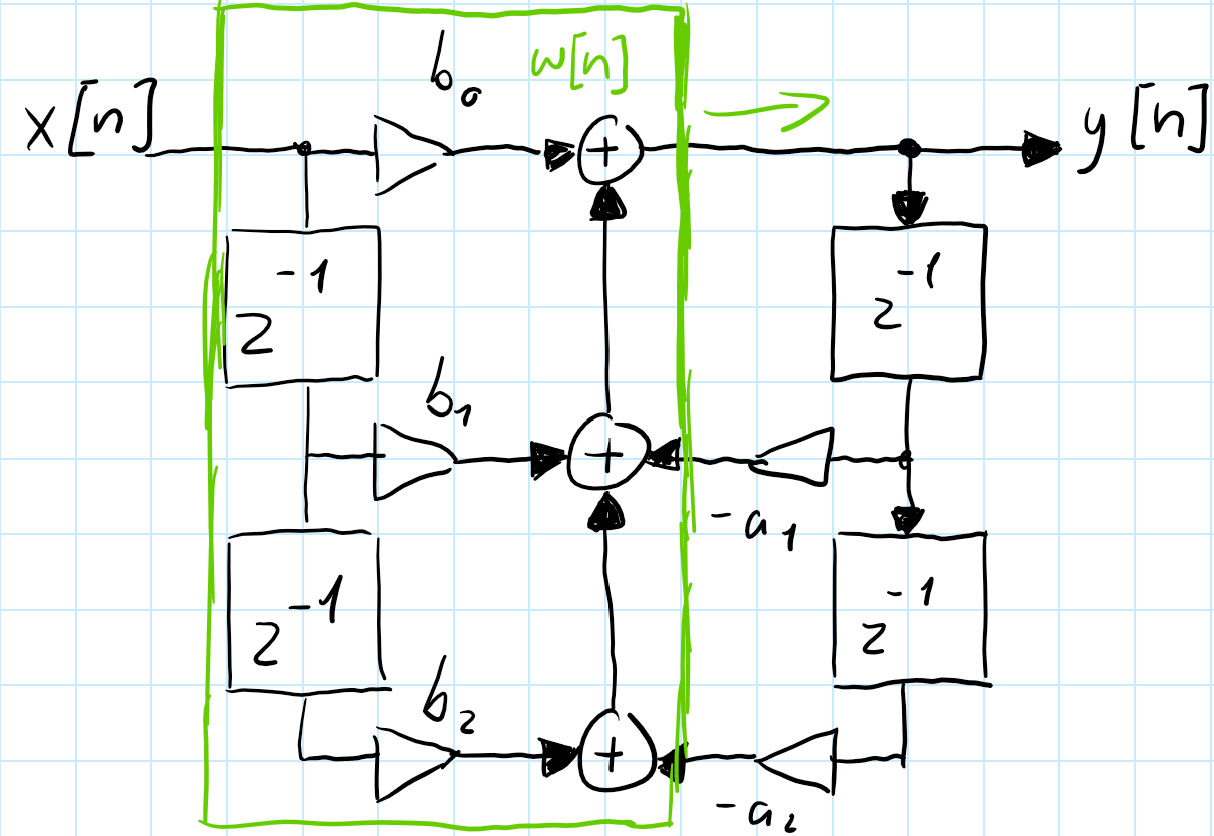
<figcaption aria-hidden="true">Signalflussbild: Direktform 1</figcaption>
</figure>

In dieser Struktur werden vier Verzögerungselemente verwendet: zwei für die Eingangsverzögerung, $x[n-1]$ und $x[n-2]$, sowie zwei für die Ausgangsverzögerung, $y[n-1]$ und $y[n-2]$. Die Multiplikationen zwischen den Verzögerungselementen und den Koeffizienten erfolgen parallel, wodurch sich eine hohe Verarbeitungsgeschwindigkeit erzielen lässt.

Die Direktform 1 zeichnet sich durch ihre konzeptionelle Einfachheit und die direkte Korrespondenz zur Differenzengleichung aus. Nachteilhaft bei dieser Struktur ist der erhöhte Speicherbedarf, aufgrund der redundanten Verzögerungselemente.

## Direktform 2 (Kanonische Form)

Die Direktform 2, oder auch als kanonische Form bekannt, ist eine optimierte Variante der Direktform 1, welche durch die Umordnung der Operationen die Anzahl der benötigten Verzögerungselemente minimiert.

Diese Struktur macht sich die Kommutativität (Vertauschbarkeit) linearer zeitinvarianter (LTI)-Systeme zunutze, indem sie die Reihenfolge von der Vorwärts- und Rückwärtsverarbeitung vertauscht.

<figure>
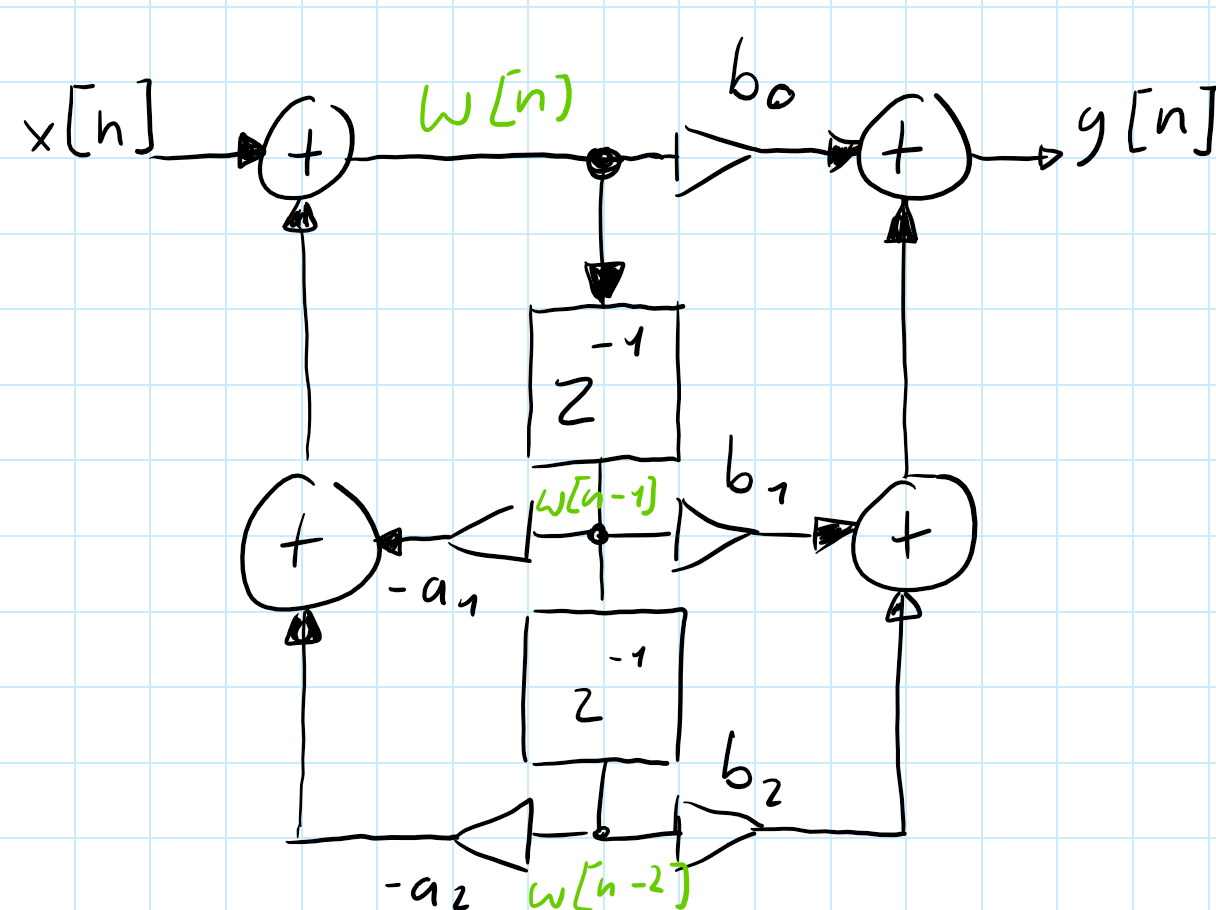
<figcaption aria-hidden="true">Signalflussbild: Direktform 2</figcaption>
</figure>

Zunächst wird ein Zwischenwert $w[n]$ durch die rekursive Beziehungen erzeugt:

$w[n] = x[n] - a_1 \cdot w[n-1] - a_2 \cdot w[n-2]$

Der Zwischenwert $w[n]$ dient als Substituion für die Verzögerungselemente der Ein- und Ausgangswerte.

$y[n] = b_0 \cdot w[n] + b_1 \cdot w[n-1] + b_2 \cdot w[n-2]$

In dieser Struktur werden nur zwei Verzögerungselemente für w\[n-1\] und w\[n-2\] benötigt, da die rekursive als auch die nicht-rekursive Verarbeitung auf diesleben verzögerten Werte zugreifen.

Die Bezeichnung “kanonisch” bezieht sich darauf, dass diese Implementierung die minimal mögliche Anzahl von Verzögerungselementen verwendet und dadurch die Speichereffizienz optimiert.

Die Direktform 2 eignet sich Ideal für Systeme mit begrenzten Speicherressourcen. Jedoch weist diese Struktur eine erhöhte Empfindlichkeit gegenüber Quantisierungseffekten auf, da die Zwischenwerte $w[n]$ größere Dynamikbereiche aufweisen können als die ursprünglichen Ein- und Ausgangswerte.

## Transponierte Direktform 2:

Die transponierte Direktform 2 kann gebildet werden mittels der Anwendung des Transpositionstheorems auf die Direktform 2. Dieses Theorem besagt, dass die Umkehrung aller Signalflussrichtungen bei gleichzeitiger Vertauschung von Eingängen und Ausgängen eine äquivalente Übertragungsfunktion ergibt. Die resultierende Struktur weist oft günstigere numerische Eigenschaften auf, als die ursprüngliche Form.

<figure>
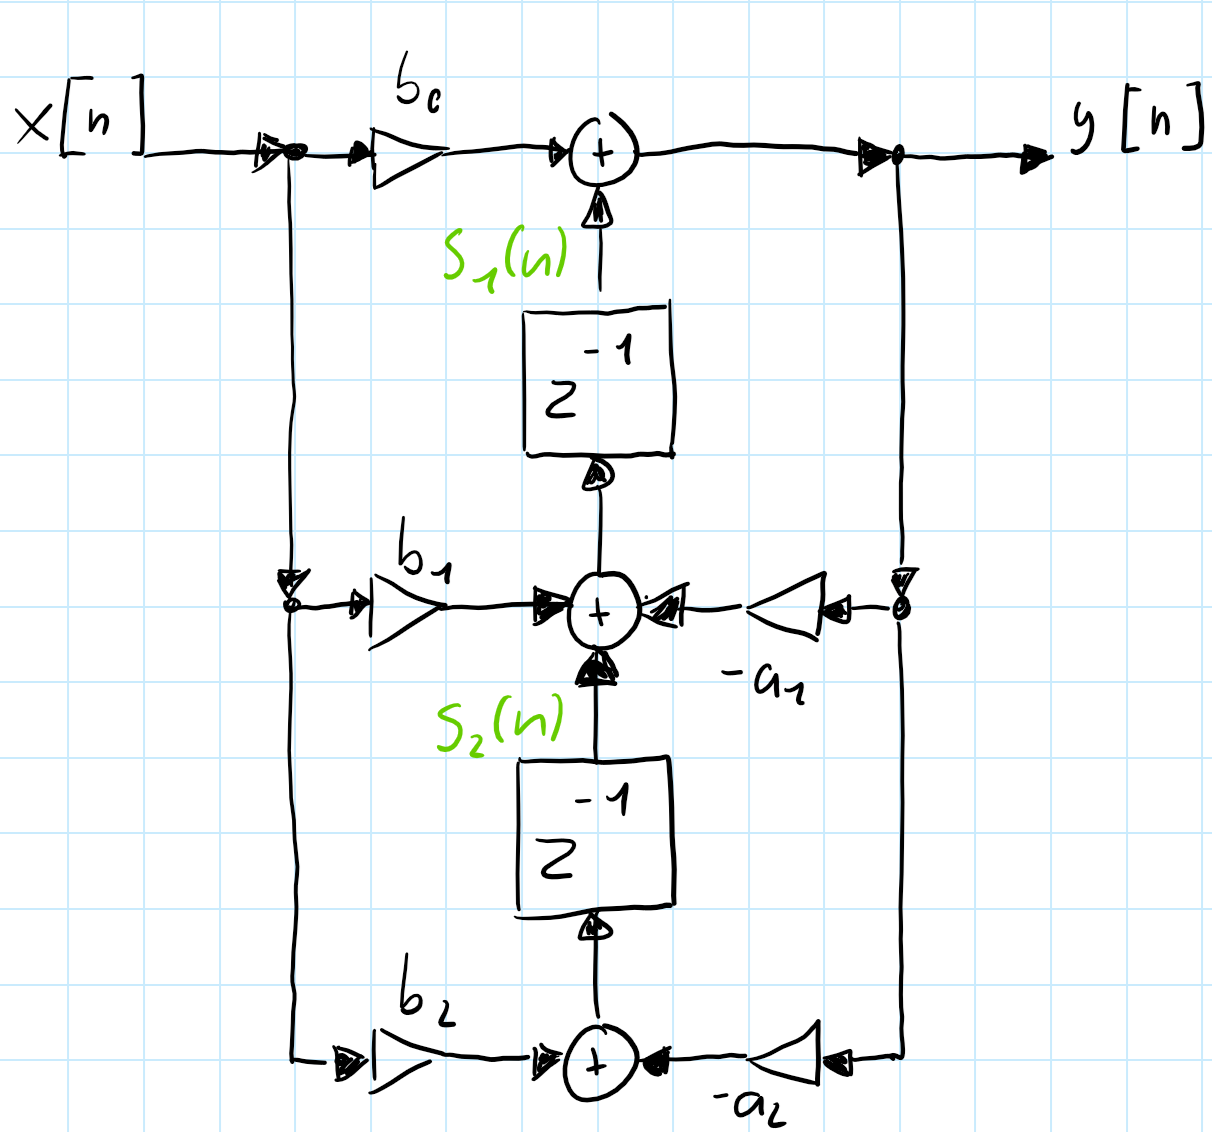
<figcaption aria-hidden="true">Signalflussbild: Transponierte Direktform 2</figcaption>
</figure>

Die transponierte Direktform 2 wird druch die folgende Differenzengleichungen beschrieben:

$s_2[n] = b_2 \cdot x[n] - a_2 \cdot y[n]$

$s_1[n] =  s_2[n] + b_1 \cdot x[n] - a_1 \cdot y[n]$

$y[n] = s_1[n] + b_0 \cdot x[n]$

Bei der transponierten Direktform 2 werden die Zwischenwerte $s_1[n]$ und $s_2[n]$ als Verzögerungselemente verwendet. Diese Struktur eignet sich besonders gut in der Implementierung von Echtzeitanwendung, aufgrund ihrer effizienten Berechnung und der guten Eignung für parallele oder pipelined Hardware-Architekturen.

Ein wesentlicher Vorteil der transponierten Direktfrom 2 liegt in ihrer reduzierten Empfindlichkeit gegenüber Koeffizientenquantisierung. Die Rückkopplungsschleifen sind kürzer als in der Direktform 2, was zu einer verbesserten numerischen Stabilität führt.